In [ ]:
pip install scikit-fem[all]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.0 MB/s eta 0:00:00


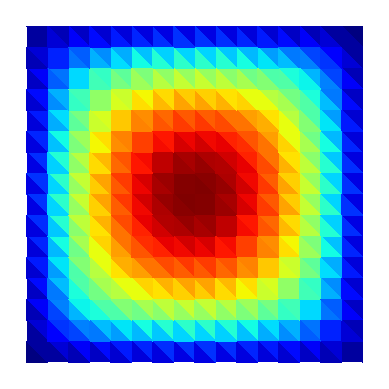

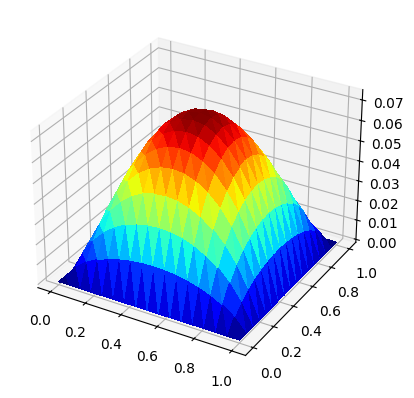

In [ ]:
from skfem import *
from skfem.autodiff import NonlinearForm
from skfem.autodiff.helpers import grad, dot
import numpy as np
import jax.numpy as jnp
from skfem.visuals.matplotlib import plot, plot3, show

# ----------------------------
# Mesh / FE space
# ----------------------------
m = MeshTri().refined(4)
basis = Basis(m, ElementTriP1())
D = m.boundary_nodes()

# ----------------------------
# Parameters
# ----------------------------
eps = 1e-3
f = 1
delta = 1

# ----------------------------
# Initialisation Newton
# ----------------------------
x = basis.project(lambda X: 1e-2 * np.sin(np.pi * X[0]) * np.sin(np.pi * X[1]))
x[D] = 0.0

@NonlinearForm(hessian=True)
def J(u, w):
    gu = grad(u)
    nrm_gu = jnp.sqrt(dot(gu, gu))
    plast = jnp.maximum(nrm_gu - 1.0, 0.0)
    return (
        0.5 * delta * dot(gu, gu)
        - f * u.value
        + (1.0 / (2.0 * eps)) * plast**2
    )

for itr in range(100):
    dx = solve(*condense(*J.assemble(basis, x=x), D=D))
    x += dx
    x[D] = 0.0
    res = np.linalg.norm(dx)

    if not np.isfinite(res):
        print("NaN détecté")
        break

    if res < 1e-8:
        break

# ----------------------------
# Plots
# ----------------------------

plot(m, x)
show()

plot3(m, x)
show()


<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\O'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_7299/3189584290.py:24: SyntaxWarning: invalid escape sequence '\p'
  ||u_h - d(., \partial\Omega)||_{0,\Omega}
/tmp/ipykernel_7299/3189584290.py:42: SyntaxWarning: invalid escape sequence '\O'
  ||grad(u_h) - grad(d)||_{L2(\Omega)}



=== delta = 5.0e-03 ===
itr=  0, step=1.056e+02, res=1.538e-02
itr= 10, step=2.485e+00, res=1.063e+00
itr= 20, step=3.114e-01, res=1.152e-01
itr= 30, step=3.590e-02, res=1.409e-02
itr= 40, step=3.918e-03, res=1.649e-02
itr= 50, step=4.211e-04, res=1.773e-03
itr= 60, step=4.522e-05, res=1.905e-04
itr= 70, step=4.855e-06, res=2.045e-05
itr= 80, step=5.213e-07, res=2.196e-06
itr= 90, step=5.598e-08, res=2.358e-07
itr=100, step=6.010e-09, res=2.532e-08
Newton converged
min=0.0000e+00, max=5.0795e-01

=== delta = 1.0e-03 ===
itr=  0, step=2.489e-02, res=1.869e-02
itr= 10, step=2.703e-03, res=2.005e-03
itr= 20, step=2.906e-04, res=2.152e-04
itr= 30, step=3.121e-05, res=2.311e-05
itr= 40, step=3.351e-06, res=2.481e-06
itr= 50, step=3.599e-07, res=2.664e-07
itr= 60, step=3.864e-08, res=2.861e-08
Newton converged
min=0.0000e+00, max=5.0371e-01

=== delta = 5.0e-04 ===
itr=  0, step=6.113e-03, res=6.322e-03
itr= 10, step=6.586e-04, res=6.787e-04
itr= 20, step=7.074e-05, res=7.288e-05
itr= 30, s

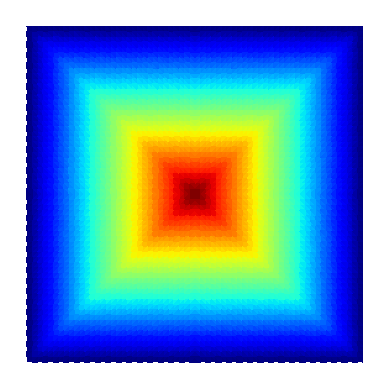

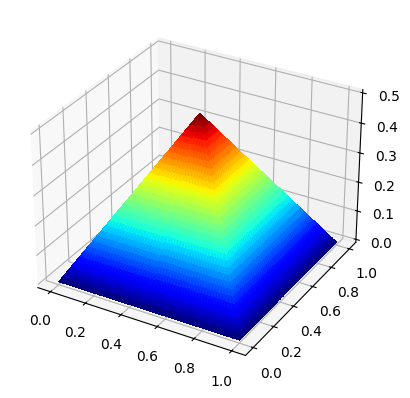

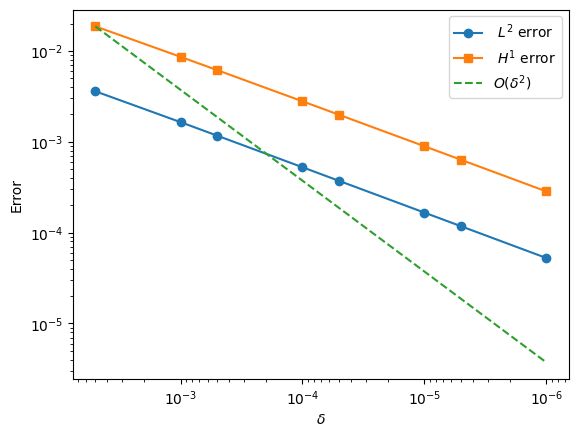


Orders of convergence
L2(Omega)   : [0.4859638  0.49456116 0.49737595 0.49872379 0.49929801 0.49962193
 0.49978327]
H1 semi     : [0.48020252 0.48735705 0.49080988 0.49322554 0.49497597 0.49642372
 0.4975476 ]

 Slope of order of convergence 
L2(Omega)   : 0.4965
H1 semi     : 0.4915
max |grad u| = 1.0004877039627822
mean |grad u| = 1.0001666657512027
min |grad u| = 1.0000052073362875


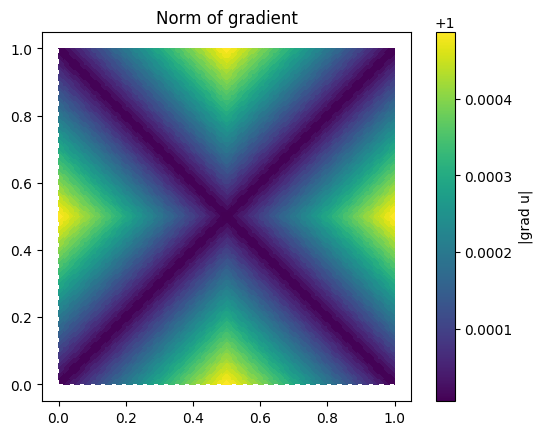

In [ ]:
from skfem import *
from skfem.autodiff import NonlinearForm
from skfem.autodiff.helpers import grad, dot
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot, plot3, show


# ==================================================
# Auxiliary functions
# ==================================================

def dist_bord_square(x, y):
    """
    Distance to the boundary of square (0,1)^2 :
        d(x,y) = min(x, 1-x, y, 1-y)
    """
    return np.minimum.reduce([x, 1.0 - x, y, 1.0 - y])


def l2_error_to_distance(basis, xvec):
    """
    ||u_h - d(., \partial\Omega)||_{0,\Omega}
    """
    uh = basis.interpolate(xvec)

    Xq = basis.global_coordinates().value
    wq = basis.dx

    xq = Xq[0]
    yq = Xq[1]

    uref_q = dist_bord_square(xq, yq)
    err_q = uh.value - uref_q

    return np.sqrt(np.sum(err_q**2 * wq))


def h1_semi_error_to_distance(basis, xvec):
    """
    ||grad(u_h) - grad(d)||_{L2(\Omega)}
    where d(x,y)=dist((x,y), \partial(0,1)^2).

    grad(d) is almost everywhere :
      - ( 1, 0) si d=x
      - (-1, 0) si d=1-x
      - ( 0, 1) si d=y
      - ( 0,-1) si d=1-y
    """
    uh = basis.interpolate(xvec)

    Xq = basis.global_coordinates().value
    wq = basis.dx

    xq = Xq[0]
    yq = Xq[1]

    d1 = xq
    d2 = 1.0 - xq
    d3 = yq
    d4 = 1.0 - yq

    all_d = np.stack([d1, d2, d3, d4], axis=0)
    k = np.argmin(all_d, axis=0)

    grad_ref = np.zeros_like(uh.grad)

    grad_ref[0] = np.where(k == 0, 1.0, grad_ref[0])   # d = x
    grad_ref[0] = np.where(k == 1, -1.0, grad_ref[0])  # d = 1-x
    grad_ref[1] = np.where(k == 2, 1.0, grad_ref[1])   # d = y
    grad_ref[1] = np.where(k == 3, -1.0, grad_ref[1])  # d = 1-y

    diff = uh.grad - grad_ref
    diff_sq = np.sum(diff**2, axis=0)

    return np.sqrt(np.sum(diff_sq * wq))


def eval_fem_on_points(basis, xvec, Xline):
    """
    Évaluate FEM solutions on Xline points of the form (2, N).
    """
    uh_fun = basis.interpolator(xvec)
    return uh_fun(Xline)


# ==================================================
# Mesh and FEM space
# ==================================================

m = MeshTri.init_sqsymmetric().refined(5)
basis = Basis(m, ElementTriP1())
D = m.boundary_nodes()
I = basis.complement_dofs(D)

def f_fun(x, y):
    return 1.0

deltas = [5e-3, 1e-3, 5e-4, 1e-4, 5e-5, 1e-5, 5e-6, 1e-6]

alpha = 0.2
maxit = 2000
tol_step = 1e-8
tol_res = 1e-8

# Initialisation Newton
x = basis.project(lambda X: 1e-2 * np.sin(np.pi * X[0]) * np.sin(np.pi * X[1]))
x[D] = 0.0

# Exact sol
u_ref = basis.project(lambda X: dist_bord_square(X[0], X[1]))

# Stockage
errs_inf = []
errs_l2_nodal = []
errs_l2 = []
errs_h1 = []
#steps_last = []
#residuals_last = []


# ==================================================
# Loop on delta
# ==================================================

for delta in deltas:
    print(f"\n=== delta = {delta:.1e} ===")

    eps = delta**0.5
    eta = 0

    @NonlinearForm(hessian=True)
    def J(u, w):
        xq = w.x[0]
        yq = w.x[1]
        fval = f_fun(xq, yq)
        gu = grad(u)
        nrm_gu = jnp.sqrt(dot(gu, gu) + eta**2)
        a = nrm_gu - 1.0
        plast = 0.5 * (a + jnp.sqrt(a**2 + eta**2))
        return (
            0.5 * delta * dot(gu, gu)
            - fval * u.value
            + (1.0 / (2.0 * eps)) * plast**2
        )

    last_step = np.nan
    last_res = np.nan
    res_hist = []

    for itr in range(maxit):
        H, g = J.assemble(basis, x=x)

        # Résidual on free dofs only
        last_res = np.linalg.norm(g[I])

        dx = solve(*condense(H, g, D=D))

        x_new = x + alpha * dx
        x_new[D] = 0.0

        last_step = np.linalg.norm(alpha * dx)

        if not np.isfinite(last_step):
            print("NaN détecté")
            break

        x = x_new

        if itr % 10 == 0 or itr == maxit - 1:
            print(f"itr={itr:3d}, step={last_step:.3e}, res={last_res:.3e}")

        if last_step < tol_step and last_res < tol_res:
          print("Newton converged")
          break

    print(f"min={x.min():.4e}, max={x.max():.4e}")


    #FEM errors
    l2_err = l2_error_to_distance(basis, x)
    h1_err = h1_semi_error_to_distance(basis, x)

    errs_l2.append(l2_err)
    errs_h1.append(h1_err)
    #steps_last.append(last_step)
    #residuals_last.append(last_res)

    #print(f"||u_h - d||_L2(Omega)     = {l2_err:.6e}")
    #print(f"|u_h - d|_H1(Omega)       = {h1_err:.6e}")


# ==================================================
# Last solution plot
# ==================================================

print("\nLast numerical solution")
plot(m, x)
show()

plot3(m, x)
show()

#print("\nReference : distance(., boundary)")
#plot(m, u_ref)
#show()

#plot3(m, u_ref)
#show()

#err = x - u_ref
#print("\nLast error: x - u_ref")
#plot(m, err)
#show()

#plot3(m, err)
#show()

# ==================================================
# Error plot with respect to delta
# ==================================================

plt.figure()
plt.loglog(deltas, errs_l2, 'o-', label=r' $L^2$ error')
plt.loglog(deltas, errs_h1, 's-', label=r' $H^1$ error')
plt.loglog(deltas, errs_h1[0] * (deltas / np.array(deltas[0]))**1, '--', label=r'$O(\delta^{2})$')
plt.xlabel(r'$\delta$')
plt.ylabel('Error')
plt.gca().invert_xaxis()
plt.legend()
plt.show()

#plt.figure()
#plt.loglog(deltas, residuals_last, 'o-', label='last residual Newton')
#plt.loglog(deltas, steps_last, 's-', label='last step Newton')
#plt.xlabel(r'$\delta$')
#plt.ylabel('quantité finale')
#plt.gca().invert_xaxis()
#plt.grid(True, which="both")
#plt.legend()
#plt.show()


# ==================================================
# Orders of convergence
# ==================================================

d = np.array(deltas)
orders_l2 = np.log(np.array(errs_l2[:-1]) / np.array(errs_l2[1:])) / np.log(d[:-1] / d[1:])
orders_h1 = np.log(np.array(errs_h1[:-1]) / np.array(errs_h1[1:])) / np.log(d[:-1] / d[1:])

print("\nOrders of convergence")
print("L2(Omega)   :", orders_l2)
print("H1 semi     :", orders_h1)

print("\n Slope of order of convergence ")
print(f"L2(Omega)   : {orders_l2.mean():.4f}")
print(f"H1 semi     : {orders_h1.mean():.4f}")

# ==================================================
# Active set plot: where |grad u| is equal to 1
# ==================================================

uh = basis.interpolate(x)
gu = uh.grad
norm_gu = np.sqrt(np.sum(gu**2, axis=0))

print("max |grad u| =", norm_gu.max())
print("mean |grad u| =", norm_gu.mean())
print("min |grad u| =", norm_gu.min())


plt.figure()
plt.tripcolor(
    m.p[0],
    m.p[1],
    m.t.T,
    facecolors=norm_gu.mean(axis=1),
    shading="flat",
)
plt.colorbar(label="|grad u|")
plt.gca().set_aspect("equal")
plt.title("Norm of gradient")
plt.show()

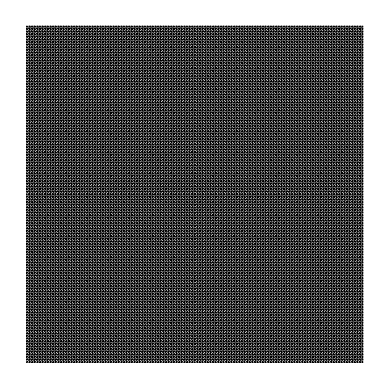

number of nodes : 16641
nombre of elements : 32768
number of dofs : 16641
h: 0.011048543456039806


In [ ]:
import matplotlib.pyplot as plt
from skfem import MeshTri
m = MeshTri.init_sqsymmetric().refined(6)

m.draw()
plt.show()

print("number of nodes :", m.p.shape[1])
print("nombre of elements :", m.t.shape[1])

basis = Basis(m, ElementTriP1())
print("number of dofs :", basis.N)

def mesh_hmax(m):
    p, t = m.p, m.t
    hmax = 0.0
    for k in range(t.shape[1]):
        verts = p[:, t[:, k]]
        lengths = [
            np.linalg.norm(verts[:, 1] - verts[:, 0]),
            np.linalg.norm(verts[:, 2] - verts[:, 1]),
            np.linalg.norm(verts[:, 0] - verts[:, 2]),
        ]
        hmax = max(hmax, *lengths)
    return hmax

print("h:",mesh_hmax(m))

In [ ]:
from skfem import *
from skfem.autodiff import NonlinearForm
from skfem.autodiff.helpers import grad, dot
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot, plot3, show


# ==================================================
# Auxiliary functions
# ==================================================


def eval_fem_on_points(basis, xvec, Xline):
    """
    Évaluate FEM solutions on Xline points of the form (2, N).
    """
    uh_fun = basis.interpolator(xvec)
    return uh_fun(Xline)


# ==================================================
# Mesh and FEM space
# ==================================================

m = MeshTri.init_sqsymmetric().refined(4)
basis = Basis(m, ElementTriP1())
D = m.boundary_nodes()
I = basis.complement_dofs(D)

def f_fun(x, y):
    #return 1.0
    return jnp.sin(2.0 * jnp.pi * x) * jnp.sin(2.0 * jnp.pi * y)
    #return x**2 + y**2

deltas = [1.0, 5e-1, 1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 5e-4, 1e-4, 1e-5, 1e-6]

alpha = 0.2
maxit = 2000
tol_step = 1e-8
tol_res = 1e-8

# Initialisation Newton
x = basis.project(lambda X: 1e-2 * np.sin(np.pi * X[0]) * np.sin(np.pi * X[1]))
x[D] = 0.0


# ==================================================
# Loop on delta
# ==================================================

for delta in deltas:
    print(f"\n=== delta = {delta:.1e} ===")

    eps = delta**1.1
    eta = 0 #np.sqrt(delta)

    @NonlinearForm(hessian=True)
    def J(u, w):
        xq = w.x[0]
        yq = w.x[1]
        fval = f_fun(xq, yq)
        gu = grad(u)
        nrm_gu = jnp.sqrt(dot(gu, gu) + eta**2)
        a = nrm_gu - 1.0
        plast = 0.5 * (a + jnp.sqrt(a**2 + eta**2))
        return (
            0.5 * delta * dot(gu, gu)
            - fval * u.value
            + (1.0 / (2.0 * eps)) * plast**2
        )

    last_step = np.nan
    last_res = np.nan

    for itr in range(maxit):
        H, g = J.assemble(basis, x=x)

        # Résidual on free dofs only
        last_res = np.linalg.norm(g[I])

        dx = solve(*condense(H, g, D=D))

        x_new = x + alpha * dx
        x_new[D] = 0.0

        last_step = np.linalg.norm(alpha * dx)

        if not np.isfinite(last_step):
            print("NaN détecté")
            break

        x = x_new

        if itr % 10 == 0 or itr == maxit - 1:
            print(f"itr={itr:3d}, step={last_step:.3e}, res={last_res:.3e}")

        if last_step < tol_step and last_res < tol_res:
          print("Newton converged")
          break

    print(f"min={x.min():.4e}, max={x.max():.4e}")

# ==================================================
# Last solution plot
# ==================================================

print("\nLast numerical solution")
plot(m, x)
show()

plot3(m, x)
show()

# ==================================================
# Active set plot: where |grad u| is close to 1
# ==================================================

uh = basis.interpolate(x)
gu = uh.grad
norm_gu = np.sqrt(np.sum(gu**2, axis=0))

print("max |grad u| =", norm_gu.max())
print("mean |grad u| =", norm_gu.mean())
print("min |grad u| =", norm_gu.min())


plt.figure()
plt.tripcolor(
    m.p[0],
    m.p[1],
    m.t.T,
    facecolors=norm_gu.mean(axis=1),
    shading="flat",
)
plt.colorbar(label="|grad u|")
plt.gca().set_aspect("equal")
plt.title("Norm of gradient")
plt.show()


=== delta = 1.0e+00 ===
itr=  0, step=1.315e-01, res=2.157e-02
itr= 10, step=1.412e-02, res=2.316e-03
itr= 20, step=1.516e-03, res=2.487e-04
itr= 30, step=1.628e-04, res=2.670e-05
itr= 40, step=1.748e-05, res=2.867e-06
itr= 50, step=1.877e-06, res=3.079e-07
itr= 60, step=2.015e-07, res=3.306e-08
itr= 70, step=2.164e-08, res=3.550e-09
Newton converged
min=0.0000e+00, max=4.7064e-02

=== delta = 5.0e-01 ===
itr=  0, step=1.621e-01, res=1.170e-02
itr= 10, step=1.741e-02, res=1.256e-03
itr= 20, step=1.869e-03, res=1.349e-04


KeyboardInterrupt: 

In [ ]:
from skfem import *
from skfem.autodiff import NonlinearForm
from skfem.autodiff.helpers import grad, dot
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot, plot3, show


# ==================================================
# Auxiliary functions
# ==================================================


def eval_fem_on_points(basis, xvec, Xline):
    """
    Évaluate FEM solutions on Xline points of the form (2, N).
    """
    uh_fun = basis.interpolator(xvec)
    return uh_fun(Xline)


# ==================================================
# Mesh and FEM space
# ==================================================

m = MeshTri.init_sqsymmetric().refined(6)
basis = Basis(m, ElementTriP1())
D = m.boundary_nodes()
I = basis.complement_dofs(D)

def f_fun(x, y):
    def G(cx, cy, s):
        return jnp.exp(-s * ((x - cx)**2 + (y - cy)**2))

    return (
        8.0  * G(0.20, 0.25, 180.0)
        + 6.0  * G(0.75, 0.70, 220.0)
        + 4.0  * G(0.35, 0.80, 150.0)
        - 7.5  * G(0.70, 0.30, 180.0)
        - 5.5  * G(0.50, 0.55, 120.0)
        + 0.35
    )

deltas = [1.0, 5e-1, 1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 5e-4, 1e-4, 5e-5, 1e-5, 5e-6, 1e-6]
alpha = 0.2
maxit = 2000
tol_step = 1e-8
tol_res = 1e-8

# Initialisation Newton
x = basis.project(lambda X: 1e-2 * np.sin(np.pi * X[0]) * np.sin(np.pi * X[1]))
x[D] = 0.0


# ==================================================
# Loop on delta
# ==================================================

for delta in deltas:
    print(f"\n=== delta = {delta:.1e} ===")

    eps = delta**1.1
    eta = np.sqrt(delta)#0

    @NonlinearForm(hessian=True)
    def J(u, w):
        xq = w.x[0]
        yq = w.x[1]
        fval = f_fun(xq, yq)
        gu = grad(u)
        nrm_gu = jnp.sqrt(dot(gu, gu) + eta**2)
        a = nrm_gu - 1.0
        plast = 0.5 * (a + jnp.sqrt(a**2 + eta**2))
        return (
            0.5 * delta * dot(gu, gu)
            - fval * u.value
            + (1.0 / (2.0 * eps)) * plast**2
        )

    last_step = np.nan
    last_res = np.nan

    for itr in range(maxit):
        H, g = J.assemble(basis, x=x)

        # Résidual on free dofs only
        last_res = np.linalg.norm(g[I])

        dx = solve(*condense(H, g, D=D))

        x_new = x + alpha * dx
        x_new[D] = 0.0

        last_step = np.linalg.norm(alpha * dx)

        if not np.isfinite(last_step):
            print("NaN détecté")
            break

        x = x_new

        if itr % 10 == 0 or itr == maxit - 1:
            print(f"itr={itr:3d}, step={last_step:.3e}, res={last_res:.3e}")

        if last_step < tol_step and last_res < tol_res:
          print("Newton converged")
          break

    print(f"min={x.min():.4e}, max={x.max():.4e}")

# ==================================================
# Last solution plot
# ==================================================

print("\nLast numerical solution")
plot(m, x)
show()

plot3(m, x)
show()

# ==================================================
# Active set plot: where |grad u| is close to 1
# ==================================================

uh = basis.interpolate(x)
gu = uh.grad
norm_gu = np.sqrt(np.sum(gu**2, axis=0))

print("max |grad u| =", norm_gu.max())
print("mean |grad u| =", norm_gu.mean())
print("min |grad u| =", norm_gu.min())

plt.figure()
plt.tripcolor(
    m.p[0],
    m.p[1],
    m.t.T,
    facecolors=norm_gu.mean(axis=1),
    shading="flat",
)
plt.colorbar(label="|grad u|")
plt.gca().set_aspect("equal")
plt.title("Norm of gradient")
plt.show()


=== delta = 1.0e+00 ===
itr=  0, step=2.568e-01, res=1.101e-02
itr= 10, step=2.746e-02, res=1.182e-03
itr= 20, step=2.946e-03, res=1.269e-04
itr= 30, step=3.163e-04, res=1.363e-05
itr= 40, step=3.396e-05, res=1.463e-06
itr= 50, step=3.647e-06, res=1.571e-07
itr= 60, step=3.916e-07, res=1.687e-08
itr= 70, step=4.205e-08, res=1.811e-09
Newton converged
min=-1.9788e-02, max=3.5179e-02

=== delta = 5.0e-01 ===
itr=  0, step=2.105e-01, res=4.652e-03
itr= 10, step=2.190e-02, res=4.976e-04
itr= 20, step=2.342e-03, res=5.340e-05
itr= 30, step=2.513e-04, res=5.733e-06
itr= 40, step=2.698e-05, res=6.156e-07
itr= 50, step=2.897e-06, res=6.610e-08
itr= 60, step=3.111e-07, res=7.097e-09
itr= 70, step=3.340e-08, res=7.621e-10
Newton converged
min=-3.3921e-02, max=5.9775e-02

=== delta = 1.0e-01 ===
itr=  0, step=1.552e+00, res=8.508e-03
itr= 10, step=5.413e-02, res=7.812e-04
itr= 20, step=5.320e-03, res=8.293e-05
itr= 30, step=5.660e-04, res=8.894e-06
itr= 40, step=6.072e-05, res=9.549e-07
itr= 50,

KeyboardInterrupt: 